## README:

* Cells labeled with '## ----- CONFIG ----- ##' contain parameters that need to be set manually

In [4]:
%%capture
!pip install FinRL
!pip install stable_baselines3
!pip install alpaca_trade_api
!pip install exchange_calendars
!pip install stockstats
!pip install wrds
!pip install websockets
!pip install yfinance
!pip install ta
!pip install sb3_contrib
!pip install dotenv

In [15]:
import os
import sys

In [16]:
# add project root to path
root_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(root_path)

In [35]:
from dotenv import load_dotenv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.nn.functional as F

from gymnasium import spaces
from finrl.meta.preprocessor.preprocessors import data_split
from sb3_contrib import RecurrentPPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnRewardThreshold
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor

from trading_environment.custom_env import StockTradingEnv
from experiments.early_stopping import MultiCondEarlyStop
from evaluation.backtest import run_backtest
from evaluation.visualize import plot_trades_on_price_from_backtest

import warnings
warnings.filterwarnings('ignore')


## Load env variables

In [18]:
load_dotenv(r'../.env')

DATA_DIR = os.getenv('DATA_DIR')

## MLP feature extractor

In [19]:
class SimpleMLP(nn.Module):
    def __init__(
        self, input_dim: int, hidden_dim: int = 64, output_dim: int = 1
    ):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.out = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x: [batch_size, input_dim]
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)
        return x

In [20]:
class MLPFeaturesExtractor(BaseFeaturesExtractor):
    """
    Wrap SimpleMLP as a feature extractor.
    """
    def __init__(
        self, observation_space: spaces.Box, features_dim: int = 64
    ):
        super().__init__(observation_space, features_dim)

        # use the latest (current) state, ignore lagged states
        input_dim = observation_space.shape[1]

        self.mlp = SimpleMLP(
            input_dim=input_dim,
            hidden_dim=features_dim,
            output_dim=features_dim
        )

    def forward(self, observations: torch.Tensor) -> torch.Tensor:
        # observations: [batch_size, 100, 71]
        x = observations[:, -1, :] # get current state
        return self.mlp(x)

## Train-test split and normalization

In [21]:
## ----- CONFIG ----- ##
SPLIT_DATE = '2018-01-01' # format %Y-%m-%d
DATA_FILE_NAME = 'data_with_features.csv'

stock_features = [
    'atr_30',
    'macd',
    'macd_hist',
    'rsi_30'
]

economy_features = [
    'CPIAUCSL',
    'DFF',
    'ICSA',
    'T10Y2Y',
    'USEPUINDXD',
    'VIXCLS',
    'doy_sin',
    'doy_cos',
    'dow_sin',
    'dow_cos'
]

In [23]:
# load finalized data
if DATA_DIR is None:
    DATA_DIR = '/content'
data_df = pd.read_csv(os.path.join(DATA_DIR, DATA_FILE_NAME))
data_df['date'] = pd.to_datetime(data_df['date'], format='%Y-%m-%d')
data_df.shape

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


(67300, 35)

In [24]:
SPLIT_DATE = pd.to_datetime(SPLIT_DATE, format='%Y-%m-%d')

# train-test split
min_date = data_df['date'].min()
max_date = data_df['date'].max()

train_df = data_split(data_df, start=min_date, end=SPLIT_DATE)
trade_df = data_split(data_df, start=SPLIT_DATE + pd.Timedelta(days=1), end=max_date)

print(train_df.shape, trade_df.shape)

(47340, 35) (19950, 35)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [25]:
stock_names = data_df['tic'].unique()
features_to_normalize = stock_features + economy_features

# normalize train/test data on training statistics
# Initialize StandardScaler
scaler = StandardScaler()

for tic in stock_names:
  for feature in features_to_normalize:
    # Fit scaler only on training data features to avoid data leakage
    train_df.loc[train_df['tic'] == tic, feature] = scaler.fit_transform(
      train_df.loc[train_df['tic'] == tic, feature].values.reshape(-1, 1))
    # Transform both training and trading data features using the fitted scaler
    trade_df.loc[trade_df['tic'] == tic, feature] = scaler.transform(
      trade_df.loc[trade_df['tic'] == tic, feature].values.reshape(-1, 1))


# check for NAs
print('Any missing values in training:', train_df.isna().any().any())
print('Any missing values in testing:', trade_df.isna().any().any())

Any missing values in training: False
Any missing values in testing: False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Environment configuration

In [26]:
## ----- CONFIG ----- ##
price = 'close'         # name of price to use for transactions / rewards
hmax = 100              # maximum number of stocks to transact at each step
initial_amount = 5000   # initial amount of cash
buy_cost_pct = 0.005    # % cost of each stock purchase
sell_cost_pct = 0.005   # % cost of each stock sale
num_stock_shares = 0    # number of starting shares
window_size = 100       # number of previous time steps to encode
reward_scaling = 1      # reward scaling

In [27]:
# environment kwargs
stock_dim = len(data_df['tic'].unique())
state_space = 1 + 2 * stock_dim + len(stock_features) * stock_dim + len(economy_features)

env_kwargs = {
    "price": price,
    "hmax": hmax,
    "initial_amount": initial_amount,
    "buy_cost_pct": [buy_cost_pct] * stock_dim,
    "sell_cost_pct": [sell_cost_pct] * stock_dim,
    "stock_dim": stock_dim,
    "state_space": state_space,
    "action_space": stock_dim,
    "reward_scaling": 1,
    "num_stock_shares": [num_stock_shares] * stock_dim,
    "price": "close",
    "stock_features": stock_features,
    "economy_features": economy_features,
    "window_size": window_size
}


## Model training

In [28]:
# build training env
env_train_vec = DummyVecEnv([lambda: Monitor(StockTradingEnv(df=train_df, **env_kwargs))])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [40]:
policy_kwargs = dict(
    net_arch=[64, 64],
    lstm_hidden_size=16,
    n_lstm_layers=1,
    shared_lstm=False,
    enable_critic_lstm=True,
    features_extractor_class=MLPFeaturesExtractor,
    features_extractor_kwargs=dict(features_dim=64),
)

model = RecurrentPPO(
    policy="MlpLstmPolicy",
    env=env_train_vec,

    # --- PPO rollout & update ---
    n_steps=64,
    batch_size=32,
    n_epochs=5,
    gamma=0.99,
    gae_lambda=0.95,

    # --- Optimization ---
    learning_rate=3e-4,
    max_grad_norm=0.5,
    clip_range=0.15,
    vf_coef=0.5,
    ent_coef=0.10,

    # --- Misc ---
    verbose=0,
    tensorboard_log=None,
    policy_kwargs=policy_kwargs,
)

In [41]:
callback = MultiCondEarlyStop(
    loss_window=4,
    max_time_seconds=7200,
    verbose=1,
)

model.learn(total_timesteps=10_000_000, callback=callback)

[MultiCondEarlyStop] train/loss = 1177.409066
[MultiCondEarlyStop] train/loss = 8764.090583
[MultiCondEarlyStop] train/loss = 3745.493147
[MultiCondEarlyStop] train/loss = 14245.115752
[MultiCondEarlyStop] train/loss = 7622.704707
[MultiCondEarlyStop] train/loss = 1308.926998
[MultiCondEarlyStop] train/loss = 27476.059226
[MultiCondEarlyStop] train/loss = 10873.902835
[MultiCondEarlyStop] train/loss = 8648.299896
[MultiCondEarlyStop] train/loss = 22847.891238
[MultiCondEarlyStop] train/loss = 47892.023792
[MultiCondEarlyStop] train/loss = 92275.219309
[MultiCondEarlyStop] train/loss = 117310.773949
[MultiCondEarlyStop] train/loss = 89241.578647
[MultiCondEarlyStop] train/loss = 96055.773948
[MultiCondEarlyStop] train/loss = 29425.047317
[MultiCondEarlyStop] train/loss = 5445.635194
[MultiCondEarlyStop] train/loss = 18564.205562
[MultiCondEarlyStop] train/loss = 19509.201633
[MultiCondEarlyStop] train/loss = 6771.117453
[MultiCondEarlyStop] train/loss = 15088.705416
[MultiCondEarlyStop]

## Quick evaluation

In [45]:
# build trading/backtest env
env_trade_vec = DummyVecEnv([lambda: Monitor(StockTradingEnv(df=trade_df, **env_kwargs))])

In [46]:
res = run_backtest(
    model,
    env_trade_vec,
    env_kwargs
)

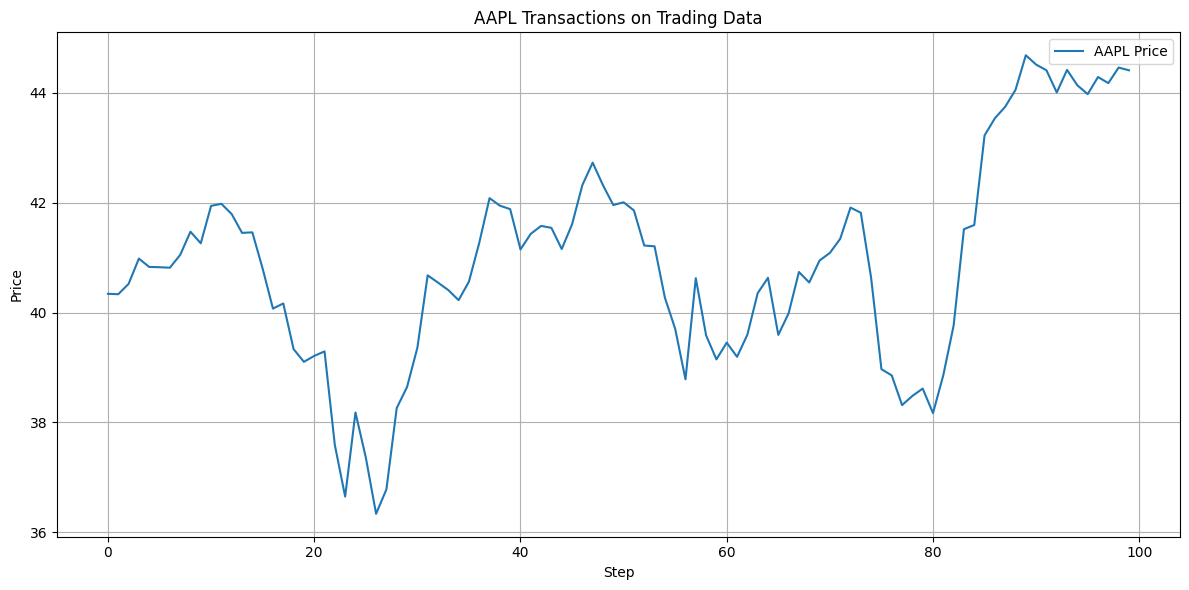

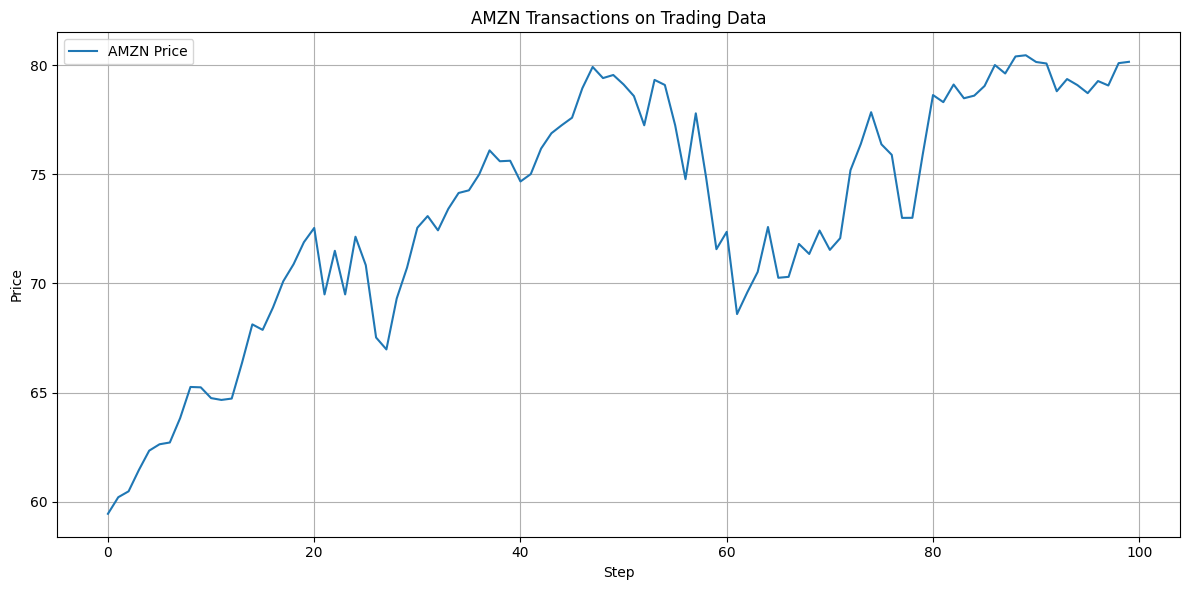

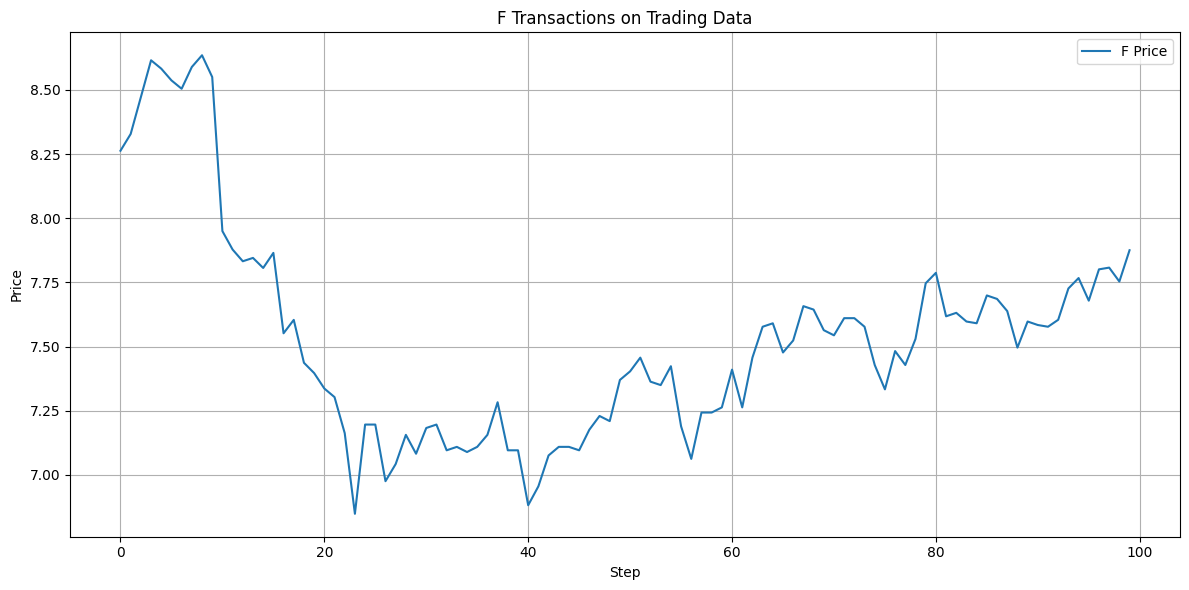

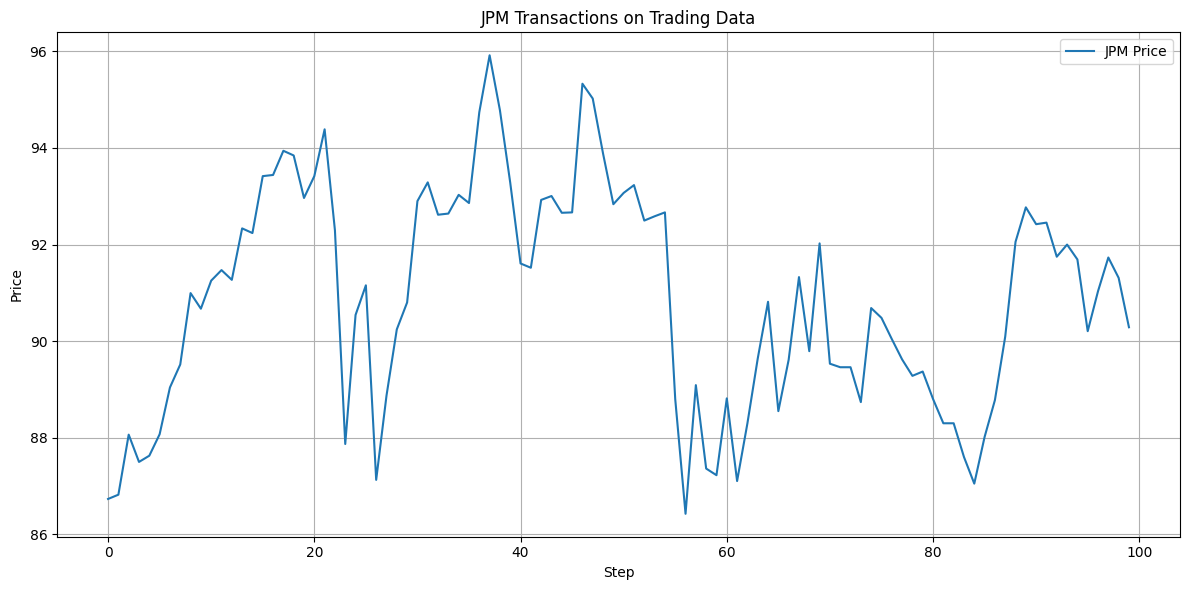

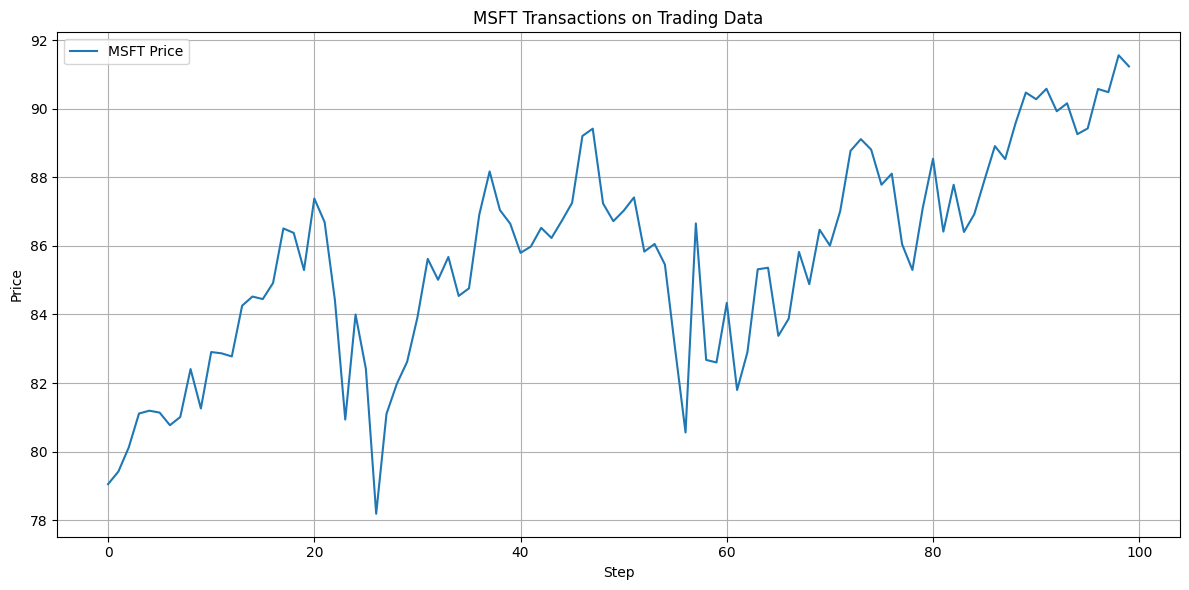

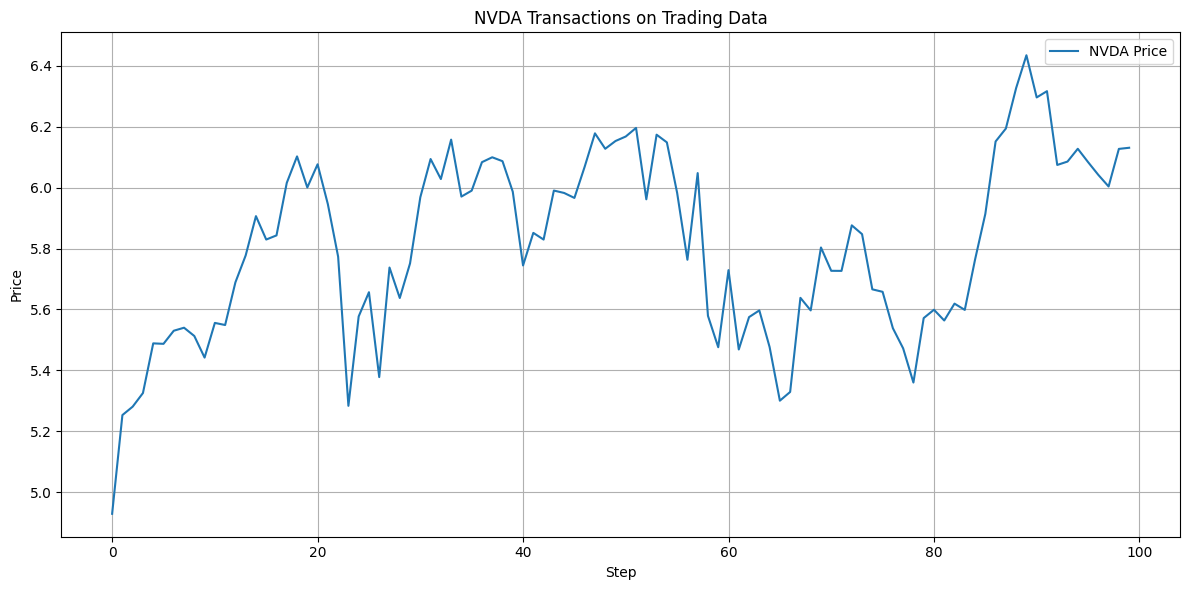

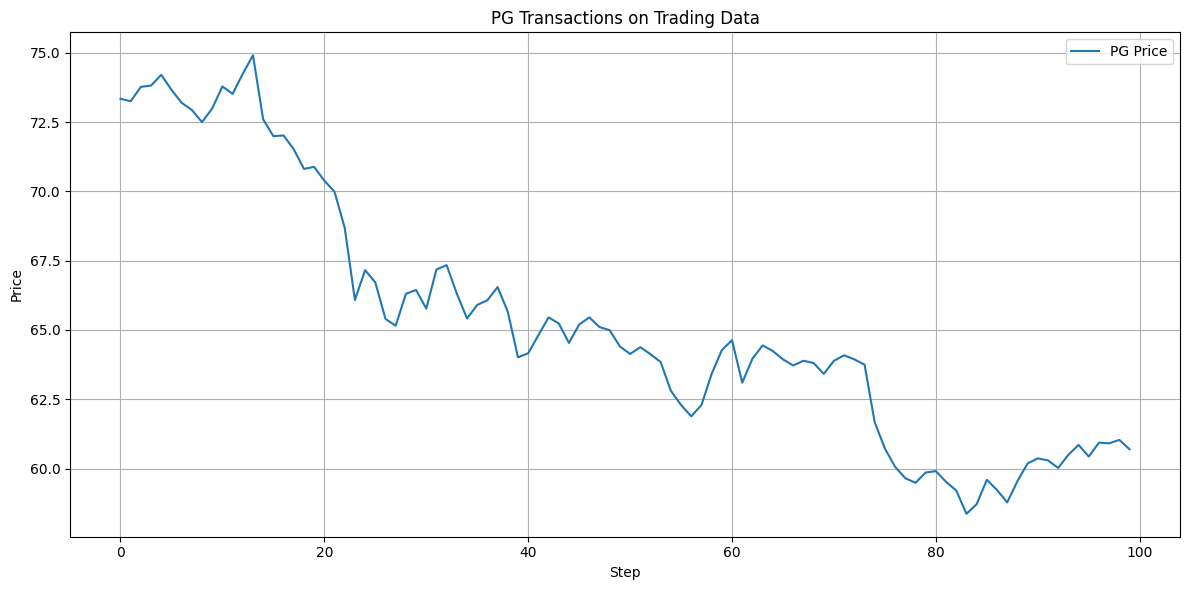

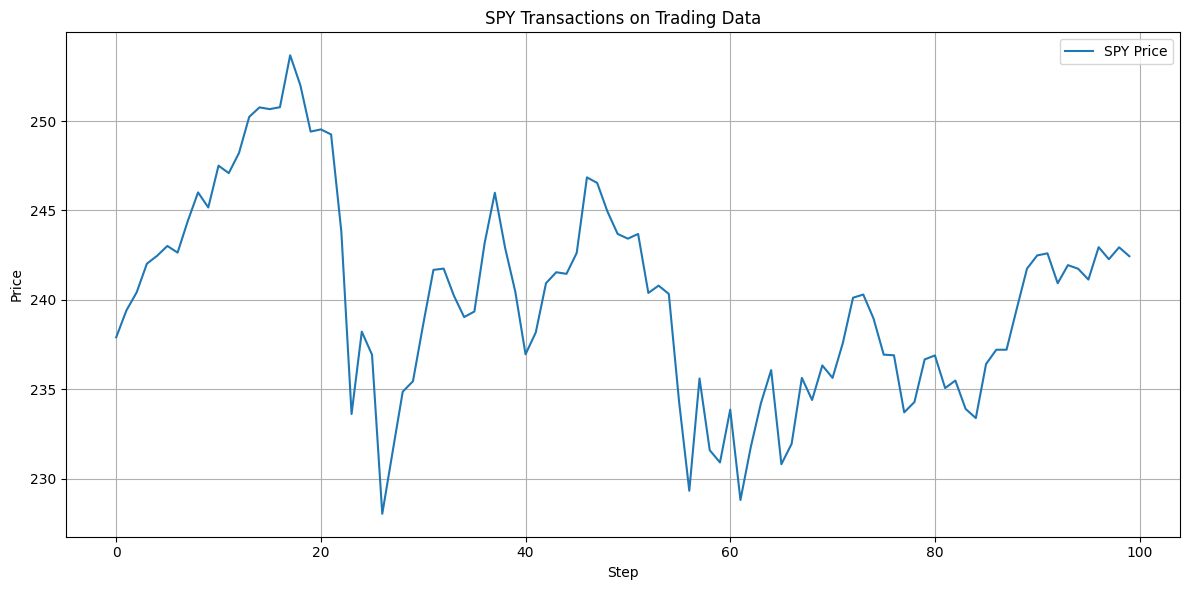

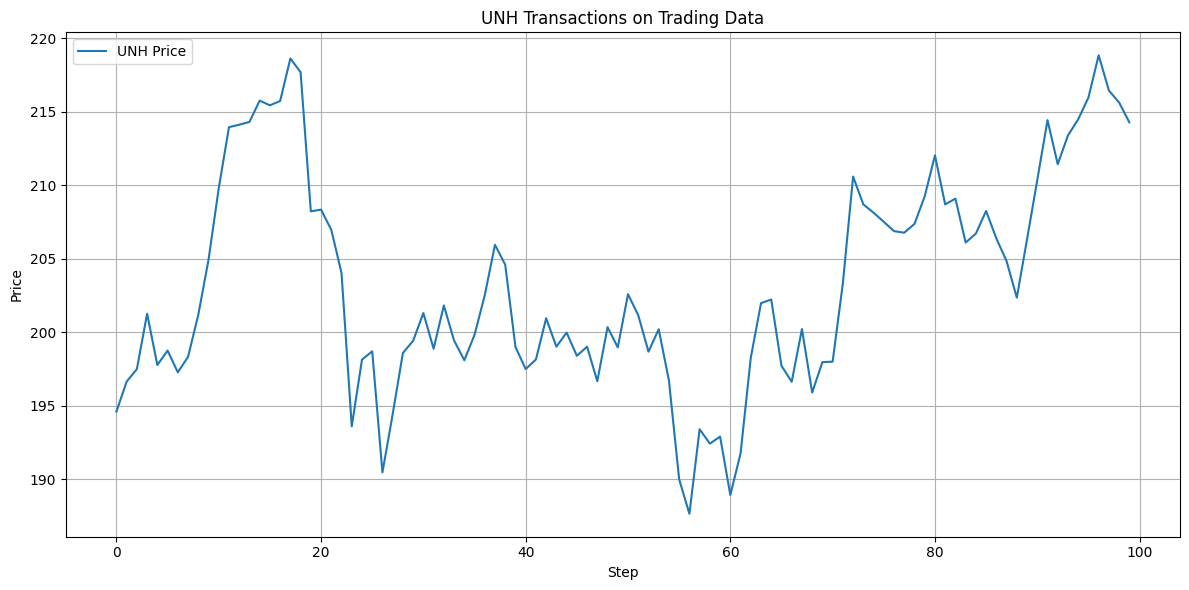

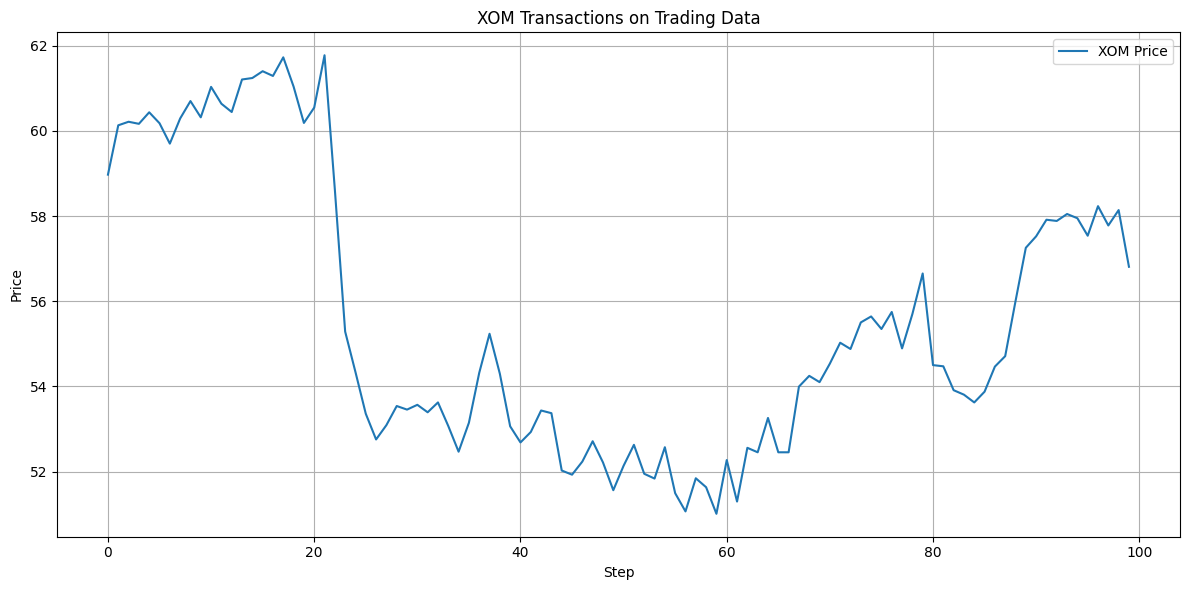

In [47]:
%matplotlib inline
tickers = trade_df['tic'].unique()

for tic in tickers:
    fig, ax = plot_trades_on_price_from_backtest(res, ticker=tic)

In [49]:
# Calculate total portfolio value if 'Total' column is missing
if 'Total' not in res.columns:
    # Start with current cash
    res['Total'] = res['cash']
    # Add value of each stock holding
    for tic in tickers:
        res['Total'] += res[f'price_{tic}'] * res[f'shares_{tic}']

final_portfolio_value = res['Total'].iloc[-1]
print(f"The final portfolio value is: {final_portfolio_value:.2f}")

The final portfolio value is: 5000.00
